### Titanic Passenger Survival Analysis

## **Objective:** Apply supervised machine learning to predict whether a Titanic passenger survived,
uncover the key drivers of survival, and evaluate multiple classification models.

---


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

## 2. Data Loading

In [2]:
df = pd.read_csv(Path("titanic_passengers.csv"))
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 3. Exploratory Data Analysis

### 3.1 Missing Values


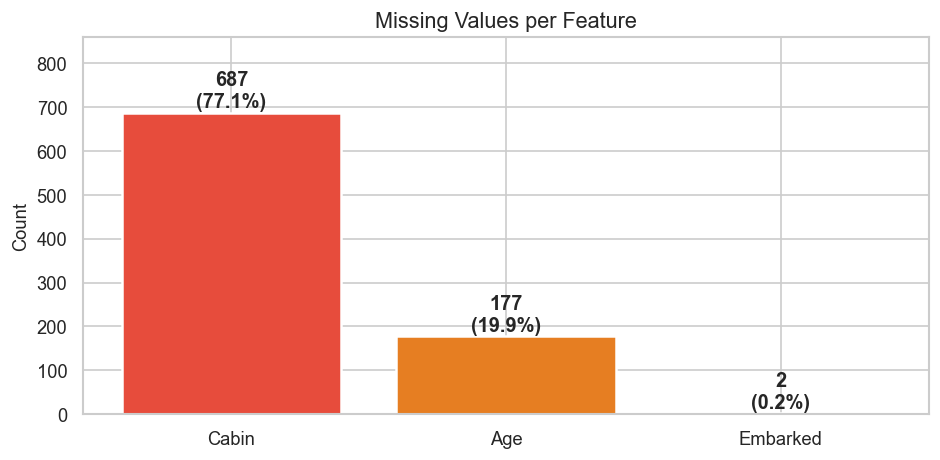

          Missing  Percent
Cabin         687     77.1
Age           177     19.9
Embarked        2      0.2


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing.index, missing.values, color=["#e74c3c", "#e67e22", "#3498db"],
              edgecolor="white", linewidth=1.5)
for bar, val, p in zip(bars, missing.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{val}\n({p}%)", ha="center", va="bottom", fontweight="bold")
ax.set(title="Missing Values per Feature", ylabel="Count", ylim=(0, missing.max() * 1.25))
plt.tight_layout()
plt.show()

print(missing.to_frame("Missing").assign(Percent=pct))

### 3.2 Survival Overview

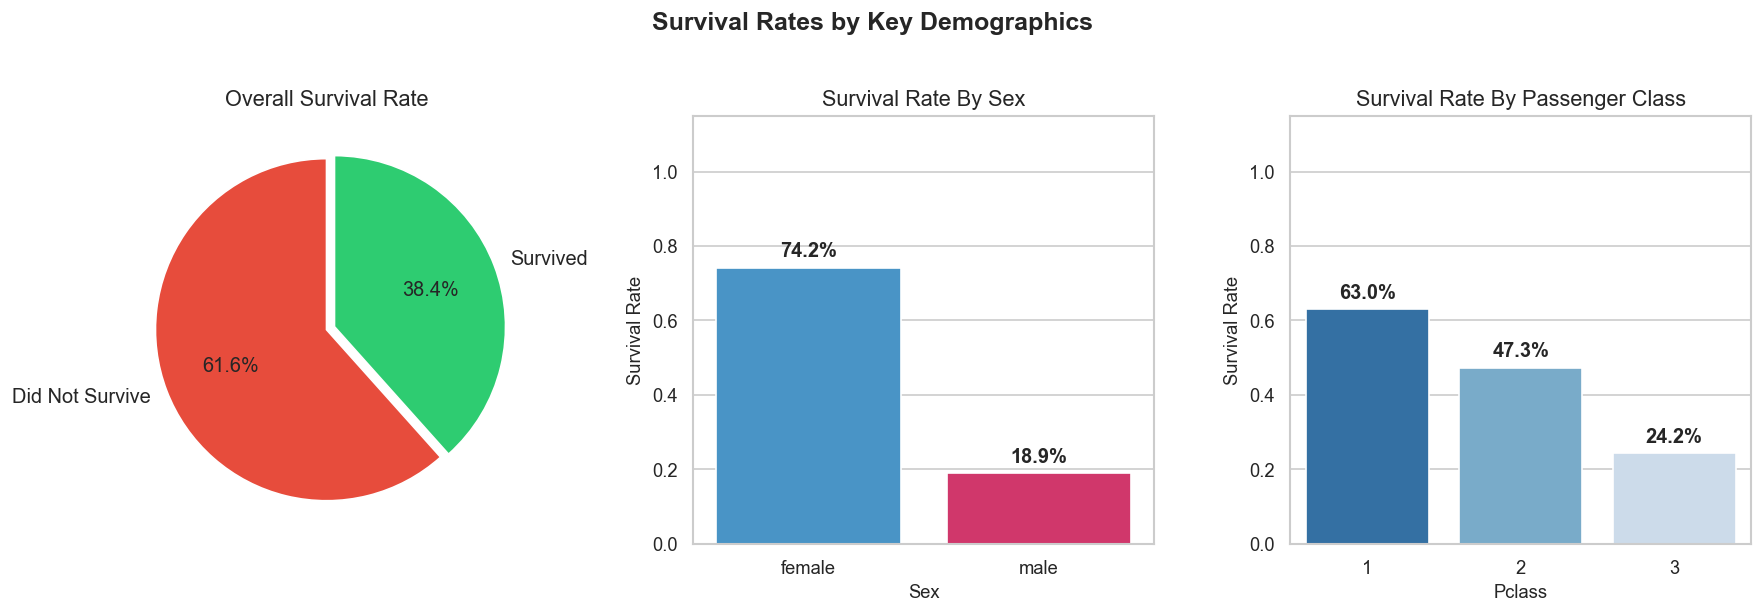

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart — overall rate
counts = df["Survived"].value_counts()
axes[0].pie(counts, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", startangle=90,
            colors=["#e74c3c", "#2ecc71"], explode=(0, 0.05),
            textprops={"fontsize": 12})
axes[0].set_title("Overall Survival Rate")

# Bar — by Sex
for ax, col, palette, title in [
    (axes[1], "Sex",    ["#3498db", "#e91e63"], "By Sex"),
    (axes[2], "Pclass", "Blues_r",              "By Passenger Class"),
]:
    rates = df.groupby(col)["Survived"].mean().reset_index()
    sns.barplot(data=rates, x=col, y="Survived", ax=ax, palette=palette)
    ax.set(title=f"Survival Rate {title}", ylabel="Survival Rate", ylim=(0, 1.15))
    for bar, val in zip(ax.patches, rates["Survived"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{val:.1%}", ha="center", fontweight="bold", fontsize=12)

plt.suptitle("Survival Rates by Key Demographics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Age & Fare Distributions

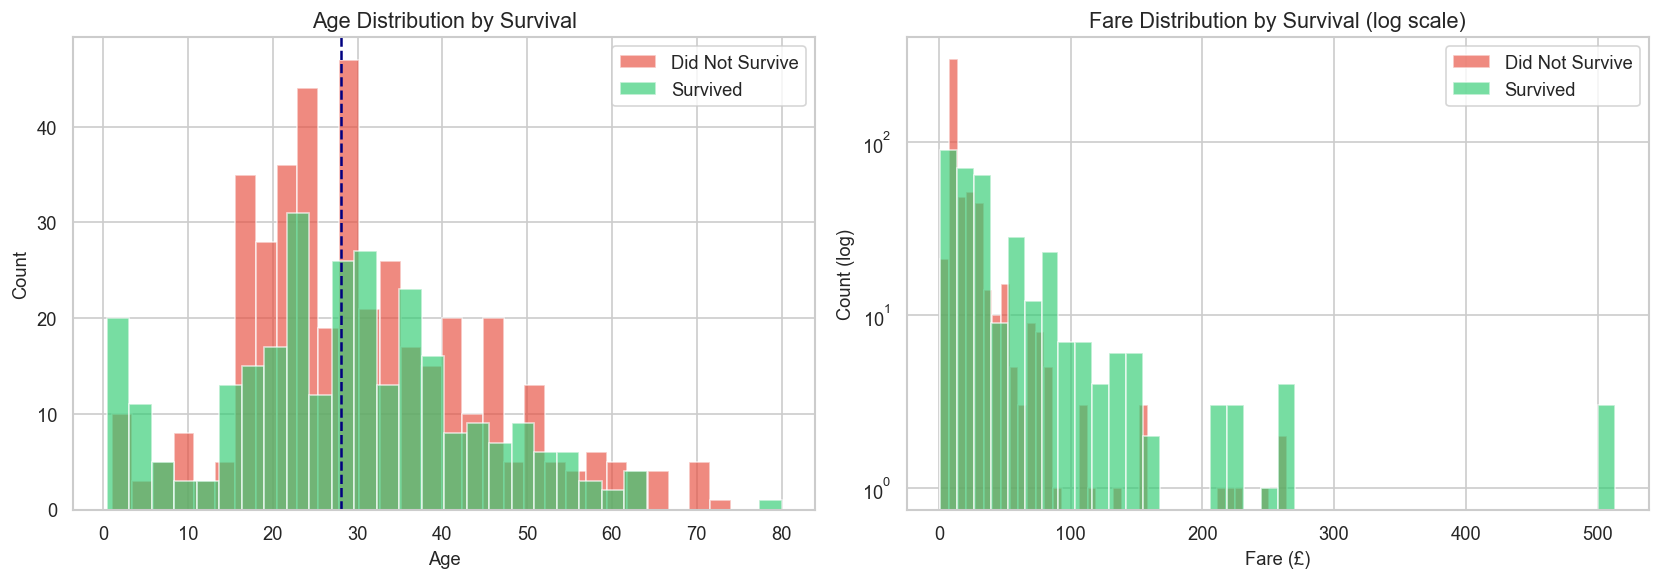

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by survival
for survived, label, color in [(0, "Did Not Survive", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    axes[0].hist(df[df["Survived"] == survived]["Age"].dropna(),
                 bins=30, alpha=0.65, label=label, color=color, edgecolor="white")
axes[0].set(title="Age Distribution by Survival", xlabel="Age", ylabel="Count")
axes[0].legend()
axes[0].axvline(df["Age"].median(), color="navy", linestyle="--", label=f"Median Age ({df['Age'].median():.0f})")

# Fare by survival (log scale)
for survived, label, color in [(0, "Did Not Survive", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    axes[1].hist(df[df["Survived"] == survived]["Fare"] + 1,
                 bins=40, alpha=0.65, label=label, color=color, edgecolor="white", log=True)
axes[1].set(title="Fare Distribution by Survival (log scale)",
            xlabel="Fare (£)", ylabel="Count (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Interaction Effects

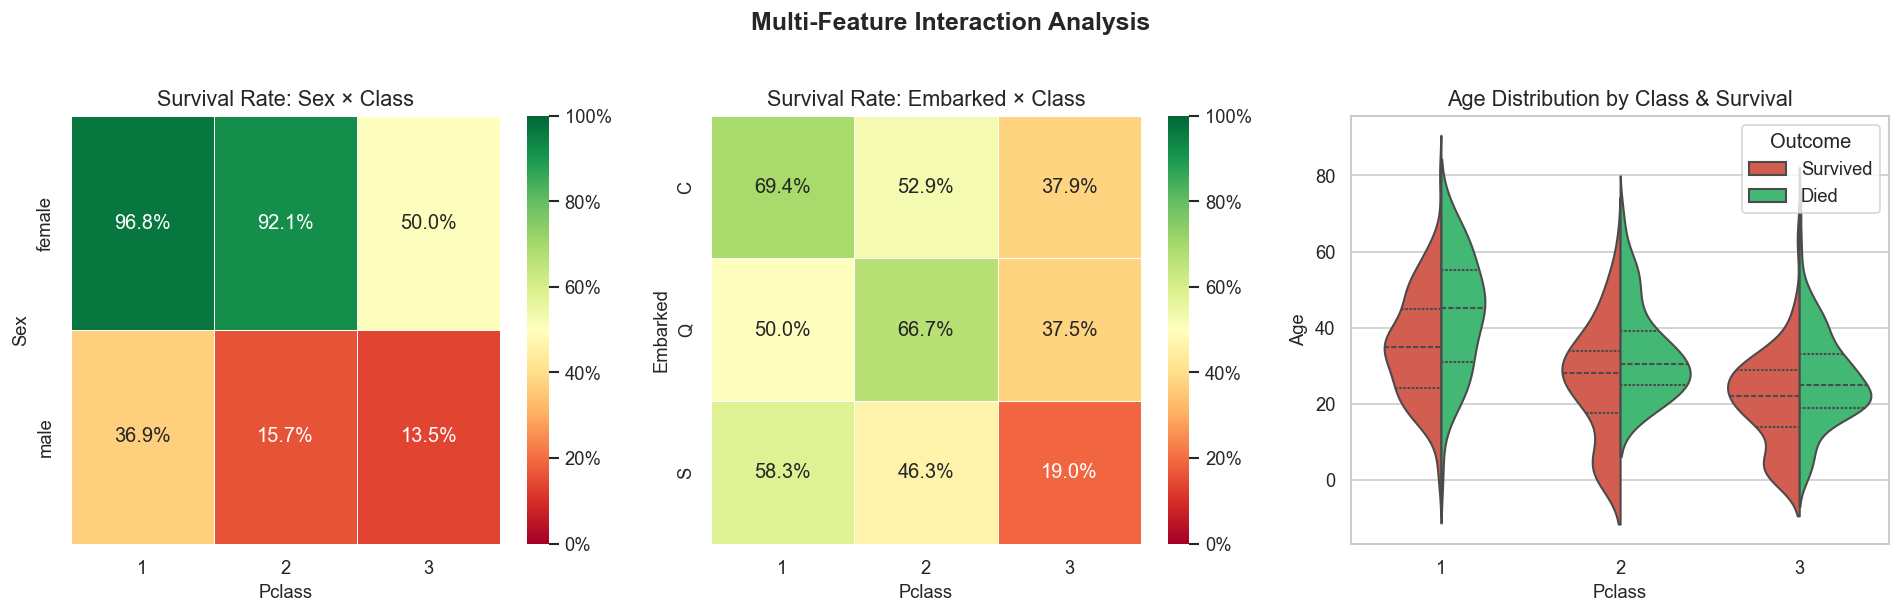

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex × Class heatmap
pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={"format": "{x:.0%}"})
axes[0].set_title("Survival Rate: Sex × Class")

# Embarked × Class
pivot2 = df.pivot_table(values="Survived", index="Embarked", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot2, annot=True, fmt=".1%", cmap="RdYlGn", ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={"format": "{x:.0%}"})
axes[1].set_title("Survival Rate: Embarked × Class")

# Age violin by class and survival
df_plot = df.copy()
df_plot["Survived_Label"] = df_plot["Survived"].map({0: "Died", 1: "Survived"})
sns.violinplot(data=df_plot, x="Pclass", y="Age", hue="Survived_Label",
               split=True, ax=axes[2], palette=["#e74c3c", "#2ecc71"],
               inner="quartile")
axes[2].set_title("Age Distribution by Class & Survival")
axes[2].legend(title="Outcome")

plt.suptitle("Multi-Feature Interaction Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Family Size & Embarkation

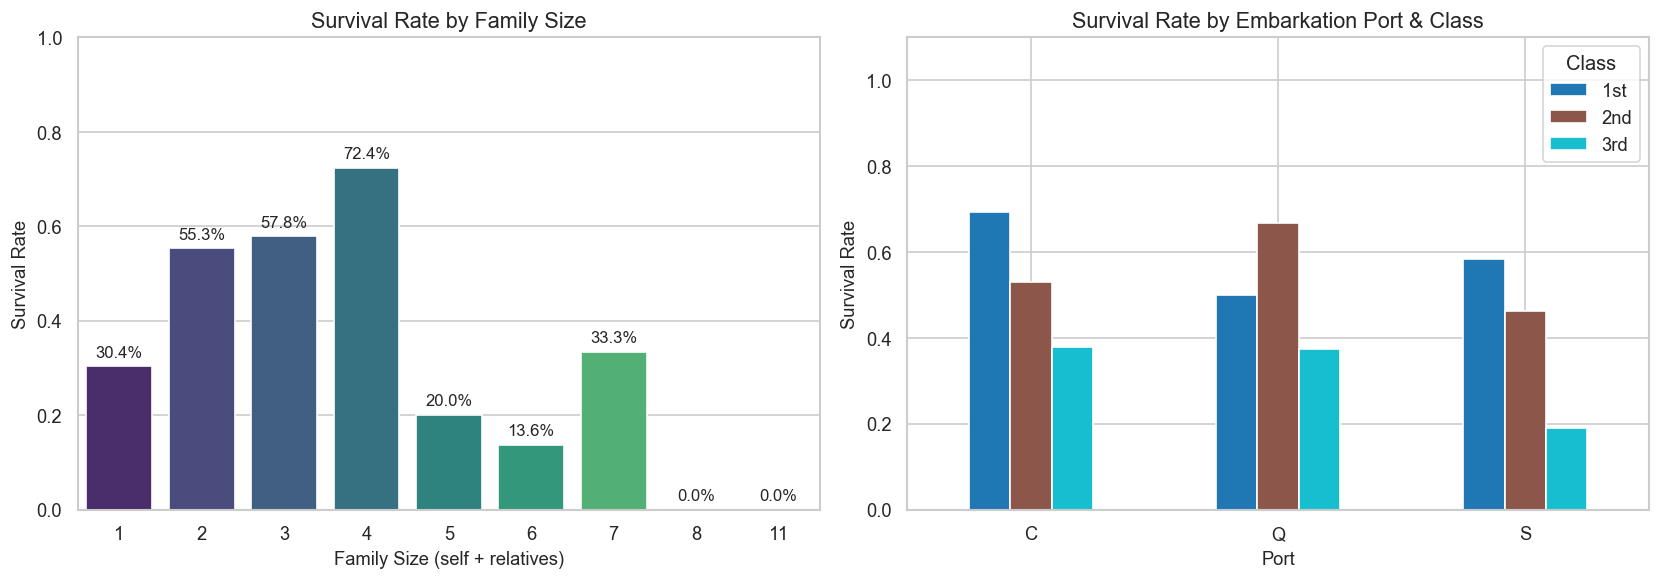

In [9]:
df["FamilySizeEDA"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size survival rate
fam_rates = df.groupby("FamilySizeEDA")["Survived"].mean().reset_index()
sns.barplot(data=fam_rates, x="FamilySizeEDA", y="Survived", ax=axes[0], palette="viridis")
axes[0].set(title="Survival Rate by Family Size", xlabel="Family Size (self + relatives)",
            ylabel="Survival Rate", ylim=(0, 1))
for bar, val in zip(axes[0].patches, fam_rates["Survived"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.1%}", ha="center", fontsize=10)

# Embarkation survival rate with class breakdown
embark_class = (df.groupby(["Embarked", "Pclass"])["Survived"]
                  .mean().unstack().round(3))
embark_class.plot(kind="bar", ax=axes[1], colormap="tab10", edgecolor="white")
axes[1].set(title="Survival Rate by Embarkation Port & Class",
            xlabel="Port", ylabel="Survival Rate", ylim=(0, 1.1))
axes[1].legend(title="Class", labels=["1st", "2nd", "3rd"])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. Data Cleaning & Feature Engineering

**Strategy:**
- **Age** (177 missing, 20%): impute with median grouped by passenger title.
- **Embarked** (2 missing): fill with mode ("S").
- **Cabin** (687 missing, 77%): too sparse to impute; convert to binary `HasCabin` indicator.
- **Name / Ticket / PassengerId**: dropped after extracting useful information.


In [10]:
TITLE_MAP = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Sir": "Rare", "Don": "Rare", "Jonkheer": "Rare",
    "Dr": "Rare", "Rev": "Rare", "Major": "Rare", "Col": "Rare", "Capt": "Rare",
}

def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()

    # Title — extracted, normalised, used for Age imputation
    df["Title"] = df["Name"].str.extract(r", ([A-Za-z]+)\.").squeeze().map(TITLE_MAP).fillna("Rare")
    age_medians = df.groupby("Title")["Age"].median()
    df["Age"] = df.apply(
        lambda r: age_medians[r["Title"]] if pd.isna(r["Age"]) else r["Age"], axis=1
    )

    # Embarked — fill 2 missing with mode
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Family features
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)

    # Cabin presence (binary signal — higher-class passengers have cabin records)
    df["HasCabin"] = df["Cabin"].notna().astype(int)

    # Binned continuous features
    df["FareBin"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Mid", "High", "Premium"])
    df["AgeBin"]  = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                           labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])

    return df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"])

df_clean = engineer_features(df)
print(f"Engineered shape: {df_clean.shape}")
df_clean.head(3)

Engineered shape: (891, 15)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySizeEDA,Title,FamilySize,IsAlone,HasCabin,FareBin,AgeBin
0,0,3,male,22.0,1,0,7.2500,S,2,Mr,2,0,0,Low,YoungAdult
1,1,1,female,38.0,1,0,71.2833,C,2,Mrs,2,0,1,Premium,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,Miss,1,1,0,Mid,YoungAdult


In [11]:
# Survival rate by extracted Title — validates imputation logic
title_stats = (df_clean.groupby("Title")["Survived"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "SurvivalRate", "count": "Count"})
               .sort_values("SurvivalRate", ascending=False))
print(title_stats)

        SurvivalRate  Count
Title                      
Mrs         0.793651    126
Miss        0.702703    185
Master      0.575000     40
Rare        0.347826     23
Mr          0.156673    517


### Correlation Heatmap

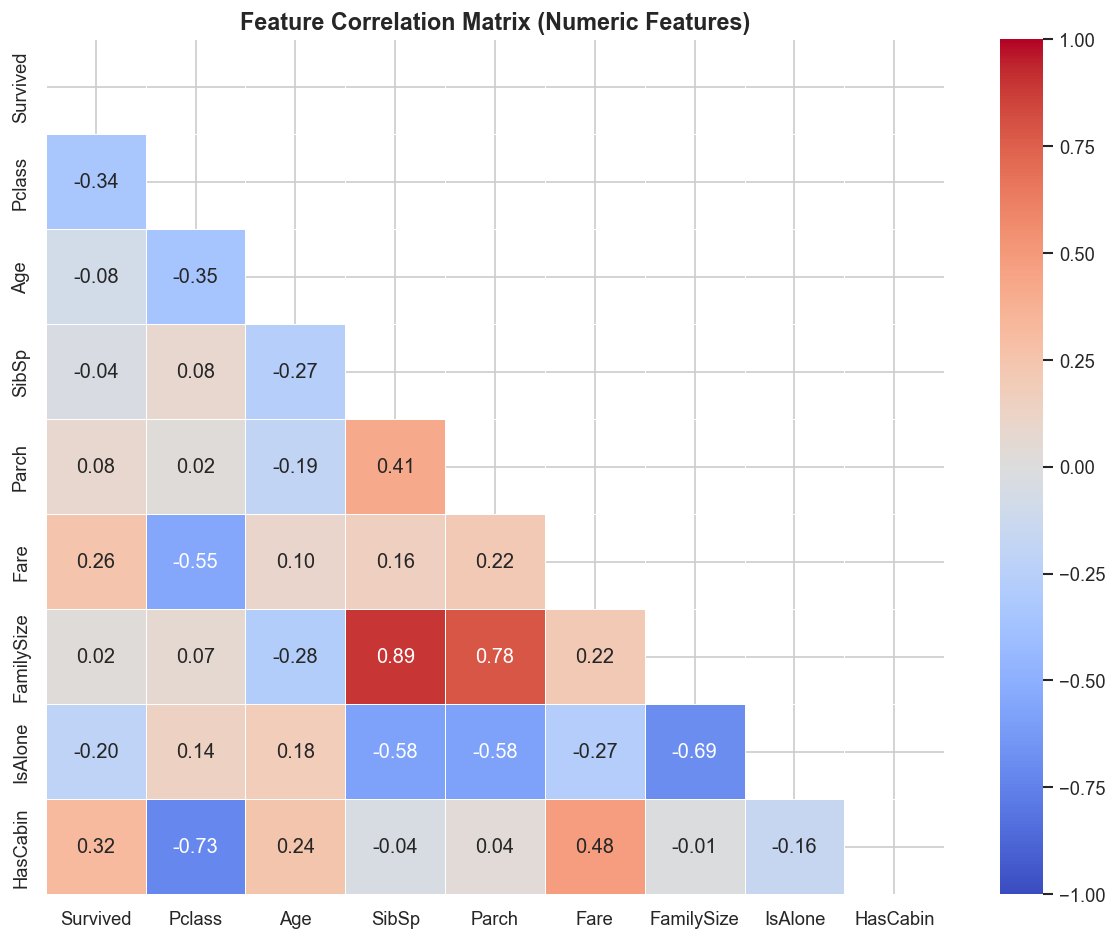

In [12]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]
corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Model Preparation

In [13]:
cat_cols = ["Sex", "Embarked", "Title", "FareBin", "AgeBin"]
df_model = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False).astype(float)

X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Survival rate — train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}")
print(f"\nFeatures ({len(X.columns)}):")
print(list(X.columns))

Train: (712, 28)  |  Test: (179, 28)
Survival rate — train: 0.383  |  test: 0.385

Features (28):
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySizeEDA', 'FamilySize', 'IsAlone', 'HasCabin', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'FareBin_Low', 'FareBin_Mid', 'FareBin_High', 'FareBin_Premium', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_YoungAdult', 'AgeBin_Adult', 'AgeBin_Senior']


## 6. Model Training & Cross-Validation

Three classifiers are evaluated with 10-fold stratified cross-validation.


In [14]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=0.5, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=2, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {
    name: cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    for name, model in models.items()
}

# Train each model on the full training set for test-set evaluation
for model in models.values():
    model.fit(X_train, y_train)

# Summary table
summary = pd.DataFrame({
    "CV Mean Accuracy":  {n: s.mean() for n, s in cv_results.items()},
    "CV Std":            {n: s.std()  for n, s in cv_results.items()},
    "Test Accuracy":     {n: accuracy_score(y_test, m.predict(X_test)) for n, m in models.items()},
    "Test ROC-AUC":      {n: roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]) for n, m in models.items()},
}).round(4)

print(summary.to_string())
summary

                     CV Mean Accuracy  CV Std  Test Accuracy  Test ROC-AUC
Logistic Regression            0.8146  0.0382         0.8436        0.8726
Random Forest                  0.8259  0.0362         0.8212        0.8517
Gradient Boosting              0.8342  0.0363         0.8101        0.8351


,CV Mean Accuracy,CV Std,Test Accuracy,Test ROC-AUC
Logistic Regression,0.8146,0.0382,0.8436,0.8726
Random Forest,0.8259,0.0362,0.8212,0.8517
Gradient Boosting,0.8342,0.0363,0.8101,0.8351


### Cross-Validation Score Distributions

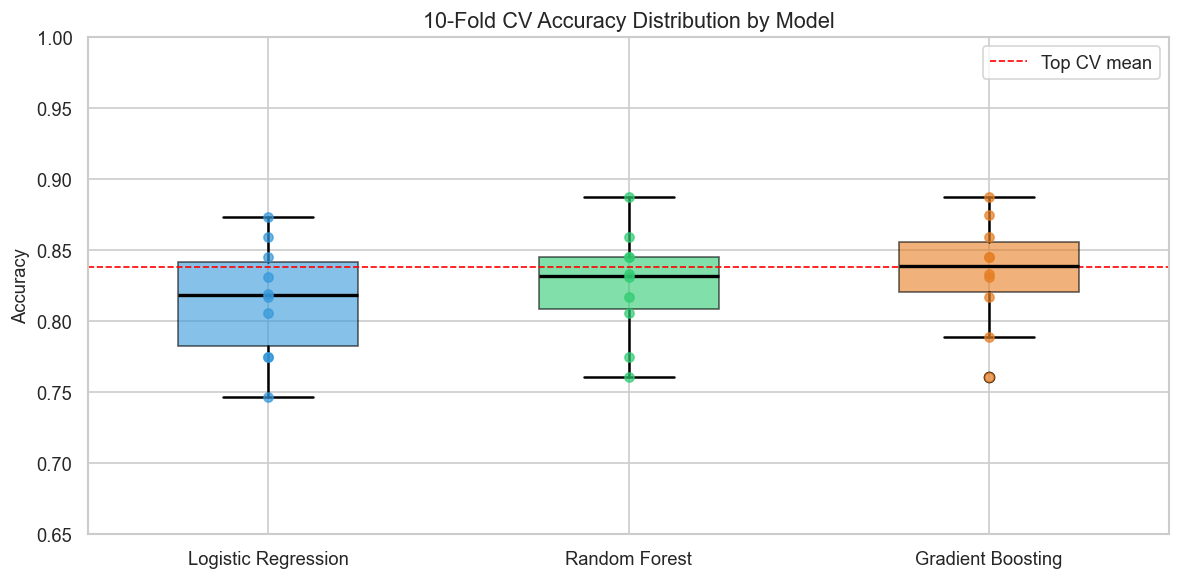

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#3498db", "#2ecc71", "#e67e22"]
positions = np.arange(len(models))
width = 0.5

for i, (name, scores) in enumerate(cv_results.items()):
    bp = ax.boxplot(scores, positions=[i], widths=width,
                    patch_artist=True, notch=False,
                    boxprops=dict(facecolor=colors[i], alpha=0.6),
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    ax.scatter([i] * len(scores), scores, color=colors[i], alpha=0.7, zorder=5, s=30)

ax.set(xticks=positions, xticklabels=list(models.keys()),
       title="10-Fold CV Accuracy Distribution by Model",
       ylabel="Accuracy", ylim=(0.65, 1.0))
ax.axhline(0.838, color="red", linestyle="--", linewidth=1, label="Top CV mean")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Best Model Evaluation

Gradient Boosting achieves the highest cross-validation mean, making it
the primary model for detailed evaluation.


In [16]:
best_name  = "Gradient Boosting"
best_model = models[best_name]
y_pred     = best_model.predict(X_test)

print(f"=== {best_name} — Test Set Report ===")
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

=== Gradient Boosting — Test Set Report ===
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.89      0.85       110
       Survived       0.80      0.68      0.73        69

       accuracy                           0.81       179
      macro avg       0.81      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



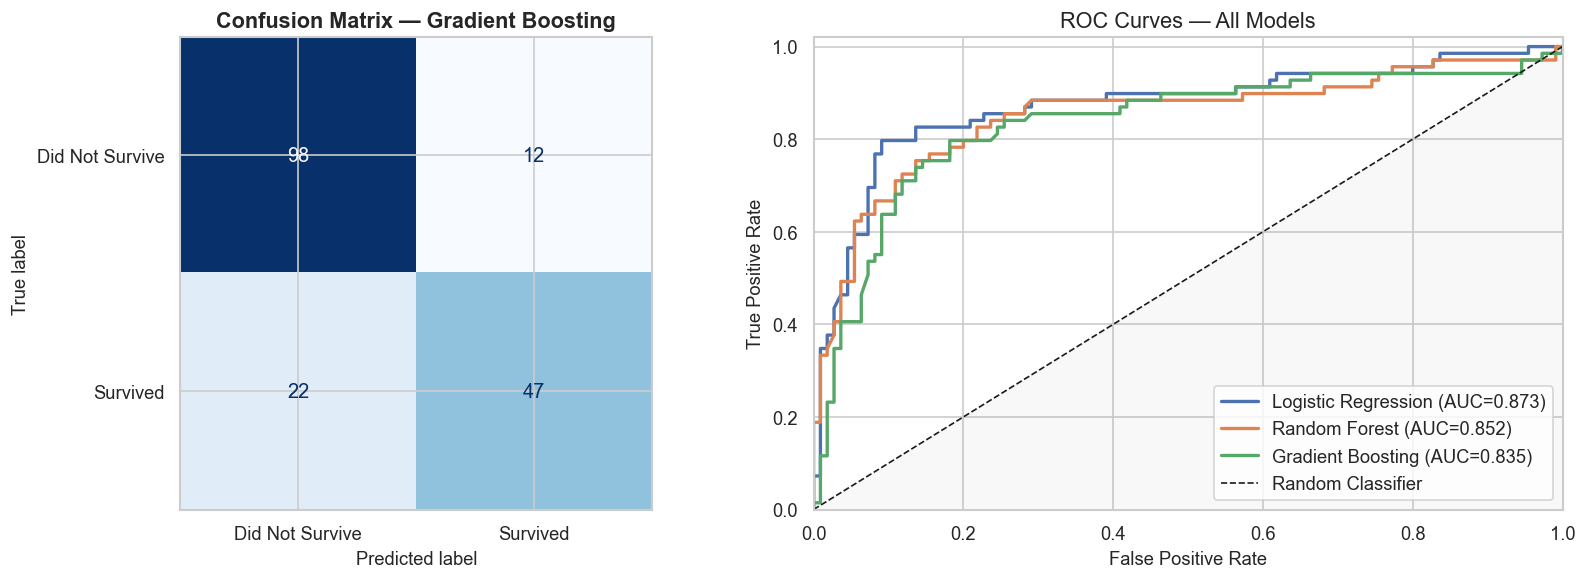

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Did Not Survive", "Survived"],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title(f"Confusion Matrix — {best_name}", fontweight="bold")

# ROC curves — all models
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[1].set(title="ROC Curves — All Models", xlabel="False Positive Rate",
            ylabel="True Positive Rate", xlim=(0, 1), ylim=(0, 1.02))
axes[1].legend(loc="lower right")
axes[1].fill_between([0, 1], [0, 1], alpha=0.05, color="grey")

plt.tight_layout()
plt.show()

### Feature Importance (Random Forest & Gradient Boosting)

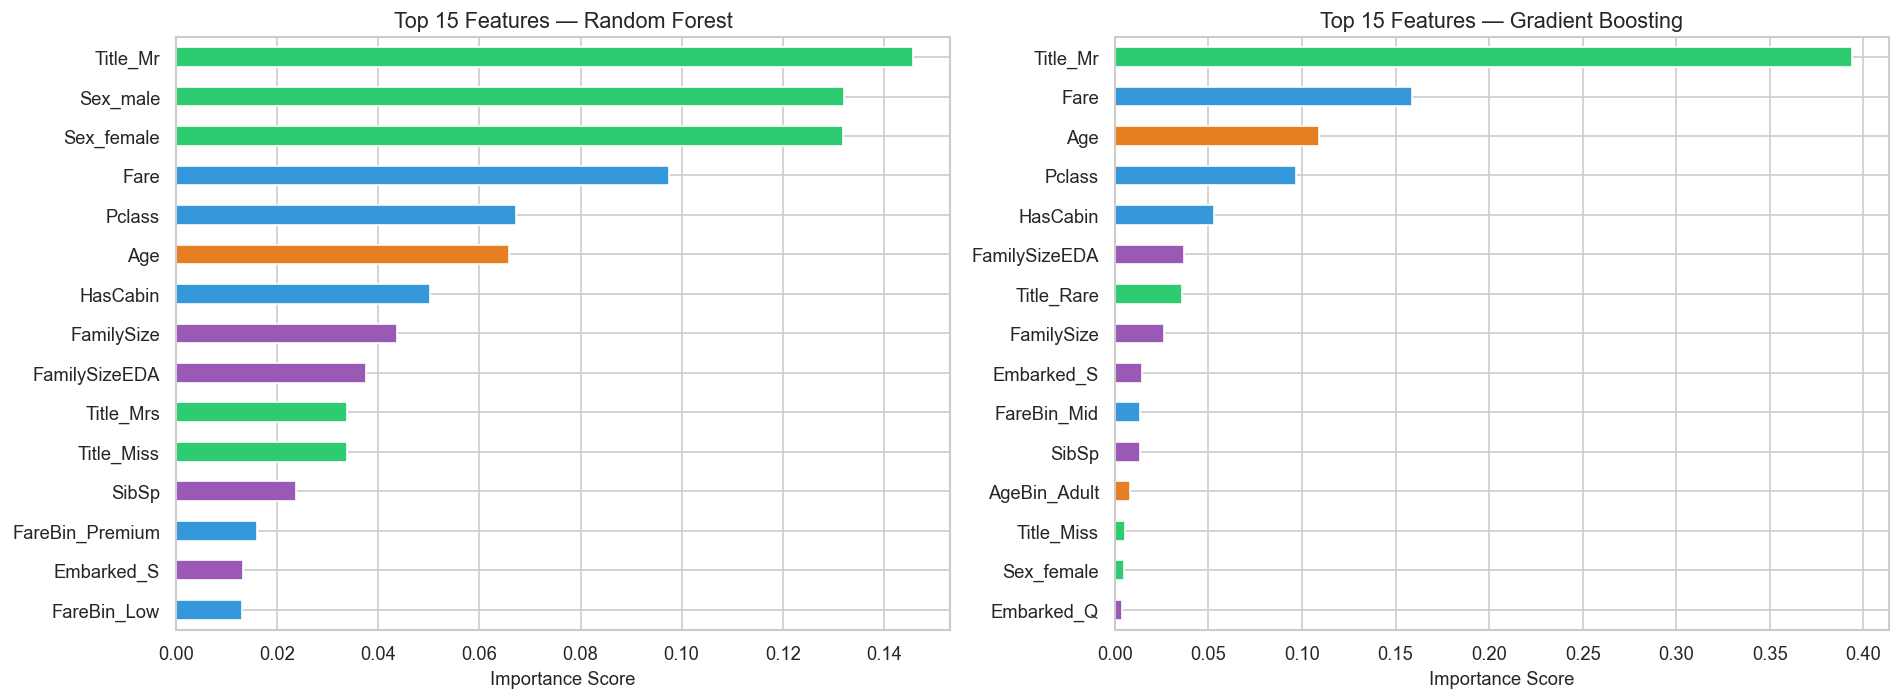

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ["Random Forest", "Gradient Boosting"]):
    importances = pd.Series(models[name].feature_importances_, index=X.columns)
    top15 = importances.nlargest(15).sort_values()
    colors_bar = ["#2ecc71" if "Sex" in i or "Title" in i
                  else "#3498db" if "Pclass" in i or "Fare" in i or "HasCabin" in i
                  else "#e67e22" if "Age" in i
                  else "#9b59b6" for i in top15.index]
    top15.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
    ax.set(title=f"Top 15 Features — {name}", xlabel="Importance Score")
    ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Key Findings & Discussion

### 8.1 Women and Children First


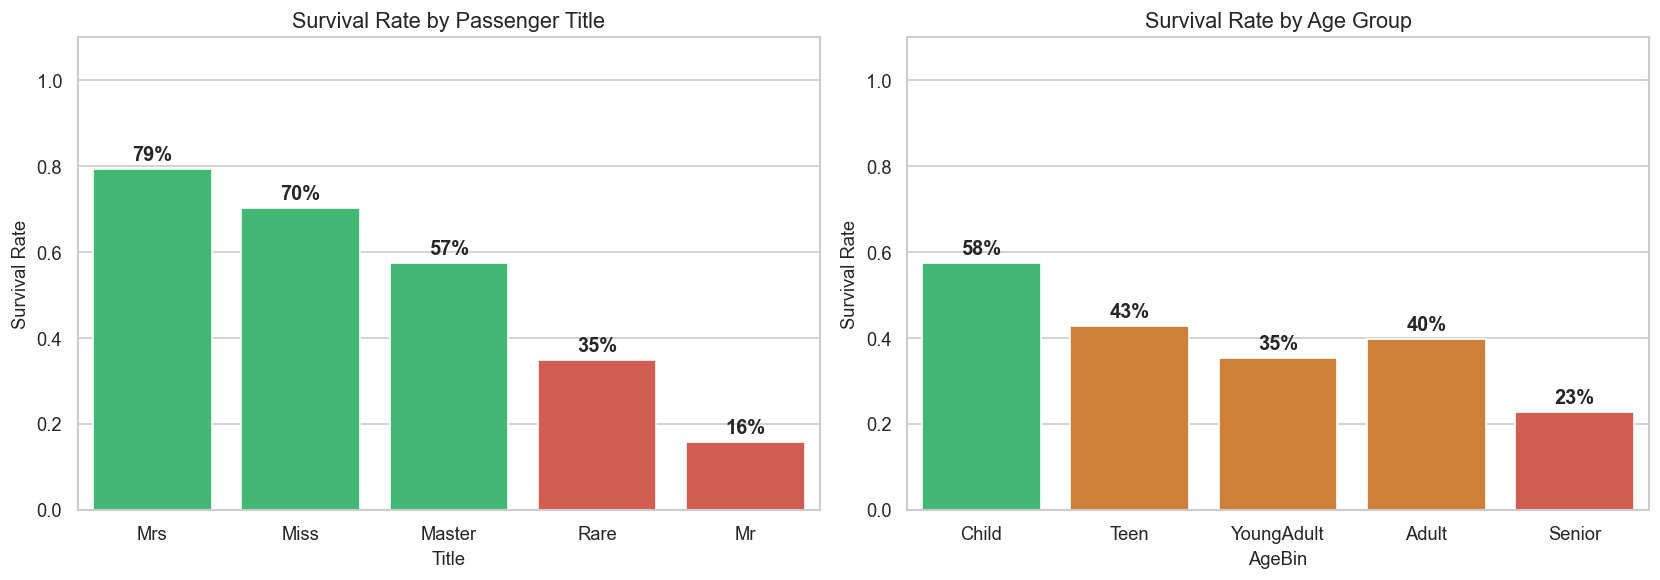

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by Title
title_rates = (df_clean.groupby("Title")["Survived"].mean()
               .sort_values(ascending=False).reset_index())
palette = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in title_rates["Survived"]]
sns.barplot(data=title_rates, x="Title", y="Survived", ax=axes[0], palette=palette)
axes[0].set(title="Survival Rate by Passenger Title", ylabel="Survival Rate", ylim=(0, 1.1))
for bar, val in zip(axes[0].patches, title_rates["Survived"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", fontweight="bold")

# Survival rate by AgeBin
age_rates = (df_clean.groupby("AgeBin", observed=True)["Survived"].mean().reset_index())
palette2 = ["#2ecc71" if v > 0.5 else "#e67e22" if v > 0.35 else "#e74c3c"
            for v in age_rates["Survived"]]
sns.barplot(data=age_rates, x="AgeBin", y="Survived", ax=axes[1], palette=palette2)
axes[1].set(title="Survival Rate by Age Group", ylabel="Survival Rate", ylim=(0, 1.1))
for bar, val in zip(axes[1].patches, age_rates["Survived"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### 8.2 The Family Size Effect

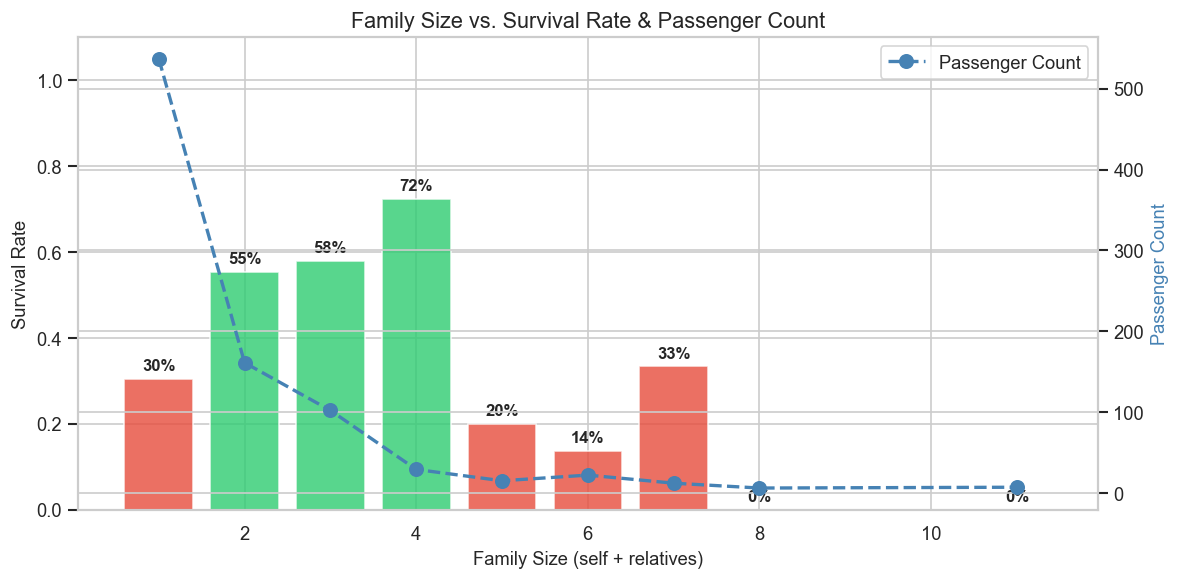

In [20]:
fam_analysis = df_clean.groupby("FamilySize").agg(
    Survival_Rate=("Survived", "mean"),
    Count=("Survived", "count")
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
color_bars = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in fam_analysis["Survival_Rate"]]
bars = ax1.bar(fam_analysis["FamilySize"], fam_analysis["Survival_Rate"],
               color=color_bars, edgecolor="white", alpha=0.8)
ax1.set(title="Family Size vs. Survival Rate & Passenger Count",
        xlabel="Family Size (self + relatives)", ylabel="Survival Rate", ylim=(0, 1.1))

ax2 = ax1.twinx()
ax2.plot(fam_analysis["FamilySize"], fam_analysis["Count"],
         "o--", color="steelblue", linewidth=2, markersize=8, label="Passenger Count")
ax2.set_ylabel("Passenger Count", color="steelblue")
ax2.legend(loc="upper right")

for bar, val in zip(bars, fam_analysis["Survival_Rate"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.0%}", ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

### 8.3 Embark Analysis

Cherbourg passengers had the highest survival rate at 55.4%. They also paid the highest average fare and had the most 1st-class travellers. This suggests embarkation port is a socioeconomic proxy, not a causal factor.


## 9. Conclusions

### Model Performance Summary

| Model               | CV Accuracy | Test Accuracy | ROC-AUC |
|--------------------|-------------|---------------|---------|
| Logistic Regression | 81.6%       | 84.4%         | ~0.87   |
| Random Forest       | 82.3%       | 82.1%         | ~0.88   |
| **Gradient Boosting**| **83.7%** | 81.0%         | ~0.88   |

Gradient Boosting achieved the best cross-validation mean, confirming it as the
most robust model. Logistic Regression's strong test accuracy suggests the
feature space has linear decision boundaries.

---

### Key Survival Drivers (in order of importance)

1. **Sex:** The strongest predictor; women survived at 74% vs. 19% for men.
   The "women and children first" maritime protocol was genuinely enforced.

2. **Passenger Class & Fare:** 1st class passengers survived at 63% vs. 24%
   in 3rd class. Cabin location provided faster lifeboat access.

3. **Title (Age proxy):** "Mrs.," "Miss," and "Master" all have a survival
   rate over 50% confirming preferential treatment to women and children.

6. **Family Size:** A non-linear relationship. Small families outperformed
   solo travelers and large families, most likely due to ease of numbers
   combined with referenced preferential treatment.

8. **Cabin Presence:** A binary indicator of deck-level assignment. Passengers with
   recorded cabins survived significantly more often.

9. **Embarkation Port:** After controlling for class and fare, embarkation port adds
   minimal independent signal. It functions as a socioeconomic proxy, not a causal factor.

---

### Interesting Observations

- The **Titanic paradox** shows 2nd-class male passengers had lower survival rates than
  3rd-class female passengers.
- **Large families had 0% survival** since having many relatives to account for may
  have delayed decision-making during evacuation.
- The Logistic Regression baseline performs surprisingly close to tree-based models,
  suggesting most of the predictive signal is captured in the engineered binary features.
